## Model Experiments

##### Importing Librares

In [1]:
import pandas as pd
import numpy as np
import shap
from sklearn.model_selection import train_test_split
import yaml
from src.utils.project_paths import ensure_project_root_on_path, get_project_root, get_config_path
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
from src.visualization.feature_importance import create_feature_importance

c:\Users\disha\OneDrive\Documents\my files\.Work\Projects\Machine Learning\Customer Churn Prediction Platform\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
ensure_project_root_on_path()
project_root = get_project_root()
config_path = get_config_path()
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

##### Loading Data

In [9]:
processed_path = project_root / config["data"]["processed_file"]
df = pd.read_csv(processed_path)

In [10]:
df.shape

(7043, 27)

##### Separate X and y

In [37]:
TARGET = config["model"]["target"]

In [38]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [39]:
y.value_counts(normalize = True)

Churn Value
0    0.73463
1    0.26537
Name: proportion, dtype: float64

##### Train/Test Split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=config["model"]["test_size"],
    random_state=config["model"]["random_state"],
    stratify=y
)

In [41]:
y_train.value_counts(
    normalize=True
)

Churn Value
0    0.734647
1    0.265353
Name: proportion, dtype: float64

In [42]:
y_test.value_counts(
    normalize=True
)

Churn Value
0    0.734564
1    0.265436
Name: proportion, dtype: float64

In [43]:
categorical_cols = (

    X_train
    .select_dtypes(
        include="object"
    )
    .columns

)

numerical_cols = (

    X_train
    .select_dtypes(
        exclude="object"
    )
    .columns

)

In [44]:
categorical_cols

Index(['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Tenure Group'],
      dtype='object')

In [45]:
numerical_cols

Index(['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV',
       'Total Services', 'Avg Monthly Spend', 'High Value Customer',
       'Monthly Contract'],
      dtype='object')

In [46]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [47]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [48]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numeric_pipeline,
            numerical_cols
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_cols
        )
    ]
)

In [49]:
models = {
    "Logistic Regression":
        LogisticRegression(
            max_iter = 1000,
            class_weight = "balanced"
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators = 200,
            class_weight = "balanced",
            random_state = config["model"]["random_state"]
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators = 300,
            learning_rate = 0.05,
            max_depth = 5,
            eval_metric = "logloss",
            random_state = config["model"]["random_state"]
        )
}

In [50]:
results = []
preds = []

for name,model in models.items():
    clf = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),

            (
                "model",
                model
            )
        ]
    )

    clf.fit(
        X_train,
        y_train
    )

    y_pred = clf.predict(
        X_test
    )

    y_prob = clf.predict_proba(
        X_test
    )[:,1]

    preds.append(
        {
            "Model":name,
            "Actual":y_test,
            "Prediction":y_pred
        }
    )

    results.append(
        {
            "Model":name,
            "Accuracy":
            accuracy_score(
                y_test,
                y_pred
            ),

            "Precision":
            precision_score(
                y_test,
                y_pred
            ),

            "Recall":
            recall_score(
                y_test,
                y_pred
            ),

            "F1":
            f1_score(
                y_test,
                y_pred
            ),

            "ROC_AUC":
            roc_auc_score(
                y_test,
                y_prob
            )
        }
    )

In [51]:
results_df = pd.DataFrame(
    results
)

results_df.sort_values(
    by = "ROC_AUC",
    ascending = False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,XGBoost,0.799858,0.645570,0.545455,0.591304,0.851863
1,Random Forest,0.779276,0.571106,0.676471,0.619339,0.843285
0,Logistic Regression,0.748048,0.517367,0.756684,0.614549,0.841461


##### Error Analysis


Logistic Regression


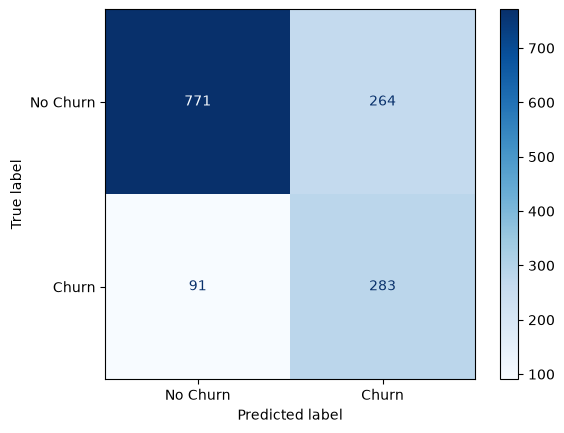


Random Forest


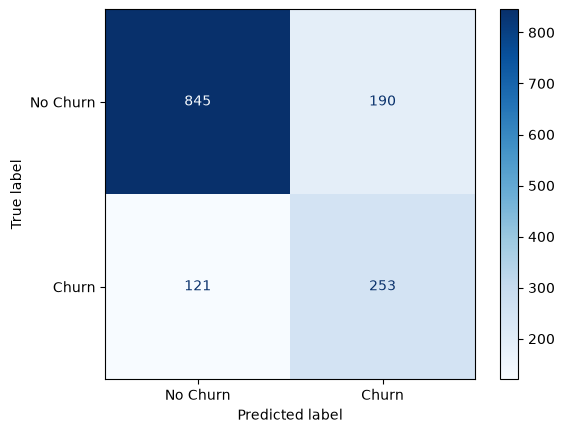


XGBoost


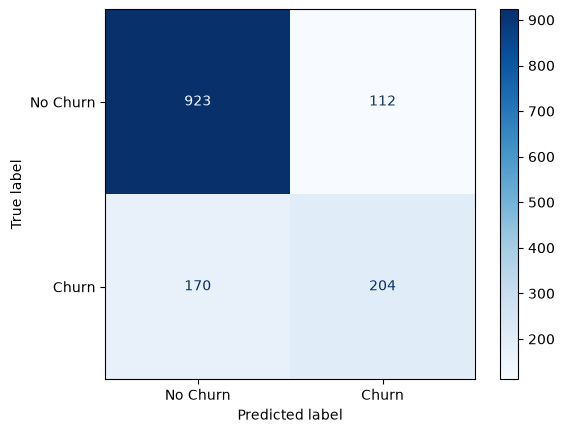

In [52]:
for p in preds:
    print(f"\n{p["Model"]}")
    cm = confusion_matrix(p["Actual"],p["Prediction"])
    disp = ConfusionMatrixDisplay(
        confusion_matrix = cm,
        display_labels = ['No Churn','Churn'])
    disp.plot(cmap = "Blues")

    plt.show()

In [53]:
for p in preds:
    print(f"\n{p["Model"]}")
    cm = confusion_matrix(p["Actual"],p["Prediction"])
    print(cm)


Logistic Regression
[[771 264]
 [ 91 283]]

Random Forest
[[845 190]
 [121 253]]

XGBoost
[[923 112]
 [170 204]]


Confusion Matrix Analysis:
1. Logistic Regression
- Highest Recall
- Lowest False Negatives (80)
- Highest False Positives (273)
- Means a lot of customers were predicted as churn but would actually stay. Marketing costs increases.
- Suitable when retaining customers is more important than reducing marketing costs.

2. Random Forest
- Best Balance between Recall and Precision
- Moderate False Negatives (122)
- Moderate False Positives (188)
- Highest F1-Score among the baseline models (Balances Recall and Precision)
- Suitable when we want both in consideration.

3. XGBoost
- Highest ROC-AUC
- Highest False Negatives (177)
- Lowest False Positives (119)
- Means this model predicts churn when its highly confident so misses a bunch of churn customers.
- Indicates that the default decision threshold of 0.5 may be too conservative.

##### Threshold Optimization

In [54]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                eval_metric="logloss",
                random_state=42
            )
        )
    ]
)

xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['City','Gender','Senior Citizen',...,'Avg Monthly Spend', 'High Value Customer','Monthly Contract']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By s

In [55]:
y_prob = xgb_pipeline.predict_proba(X_test)[:,1]
pd.Series(y_prob).describe()

count    1409.000000
mean        0.263678
std         0.265279
min         0.000494
25%         0.029768
50%         0.160818
75%         0.469352
max         0.963765
dtype: float64

In [56]:
thresholds = np.arange(0.20,0.71,0.05) ## Creates thresholds of intervals from 0.3 to 0.71 with 0.05 intervals
thresholds

array([0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 ])

In [57]:
results = []

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

    if round(threshold,1) in (0.2,0.3,0.5,0.7):
        print(f"Threshold: {threshold}")
        cm = confusion_matrix(y_test,y_pred)
        print(cm)

Threshold: 0.2
[[702 333]
 [ 56 318]]
Threshold: 0.25
[[752 283]
 [ 71 303]]
Threshold: 0.3
[[789 246]
 [ 84 290]]
Threshold: 0.49999999999999994
[[923 112]
 [170 204]]
Threshold: 0.5499999999999999
[[962  73]
 [198 176]]
Threshold: 0.7
[[1009   26]
 [ 271  103]]


In [58]:
threshold_df = pd.DataFrame(results)
threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.20,0.723918,0.488479,0.850267,0.620488
1,0.25,0.748758,0.517065,0.810160,0.631250
2,0.30,0.765791,0.541045,0.775401,0.637363
3,0.35,0.777147,0.563025,0.716578,0.630588
4,0.40,0.779276,0.572748,0.663102,0.614622
5,0.45,0.791341,0.606383,0.609626,0.608000
6,0.50,0.799858,0.645570,0.545455,0.591304
7,0.55,0.807665,0.706827,0.470588,0.565008
8,0.60,0.804826,0.748744,0.398396,0.520070
9,0.65,0.796309,0.770186,0.331551,0.463551


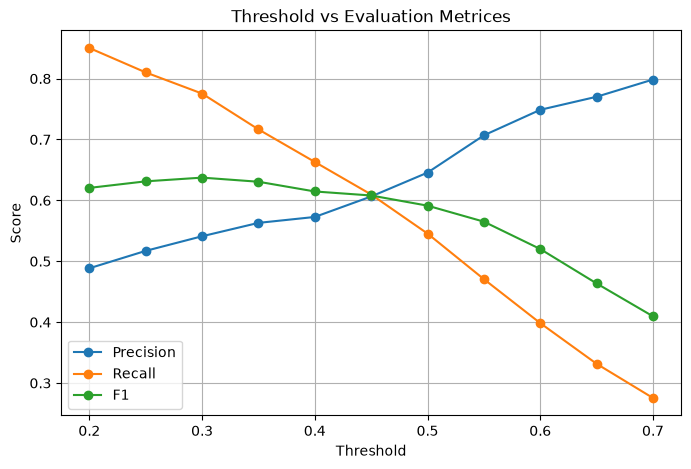

In [59]:
plt.figure(figsize = (8,5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker = "o",
    label = "Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker = "o",
    label = "Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker = "o",
    label = "F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Evaluation Metrices")
plt.grid(True)
plt.legend()

plt.show()

Threshold Optimization:
The default classification threshold of 0.5 is not always optimal. 
Different thresholds were evaluated to understand the trade-off between precsion and recall.

Observations:
- Lower thresholds increased recall by identifying more churning customers.
- Higher thresholds increased precision by reducing false positive predictions.
- The optimal threshold depends on the business objective rather than model performace alone.

For customer churn prediction, maximizing recall may be preferred because losing a customer is generally more expensive than contacting a customer who would not churn.

In [60]:
xgb_model =  xgb_pipeline.named_steps["model"]
preprocessor = xgb_pipeline.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()

In [61]:
print(feature_names[:20])
print(len(feature_names))

['numerical__Tenure Months' 'numerical__Monthly Charges'
 'numerical__Total Charges' 'numerical__CLTV' 'numerical__Total Services'
 'numerical__Avg Monthly Spend' 'numerical__High Value Customer'
 'numerical__Monthly Contract' 'categorical__City_Acampo'
 'categorical__City_Acton' 'categorical__City_Adelanto'
 'categorical__City_Adin' 'categorical__City_Agoura Hills'
 'categorical__City_Aguanga' 'categorical__City_Ahwahnee'
 'categorical__City_Alameda' 'categorical__City_Alamo'
 'categorical__City_Albany' 'categorical__City_Albion'
 'categorical__City_Alderpoint']
1182


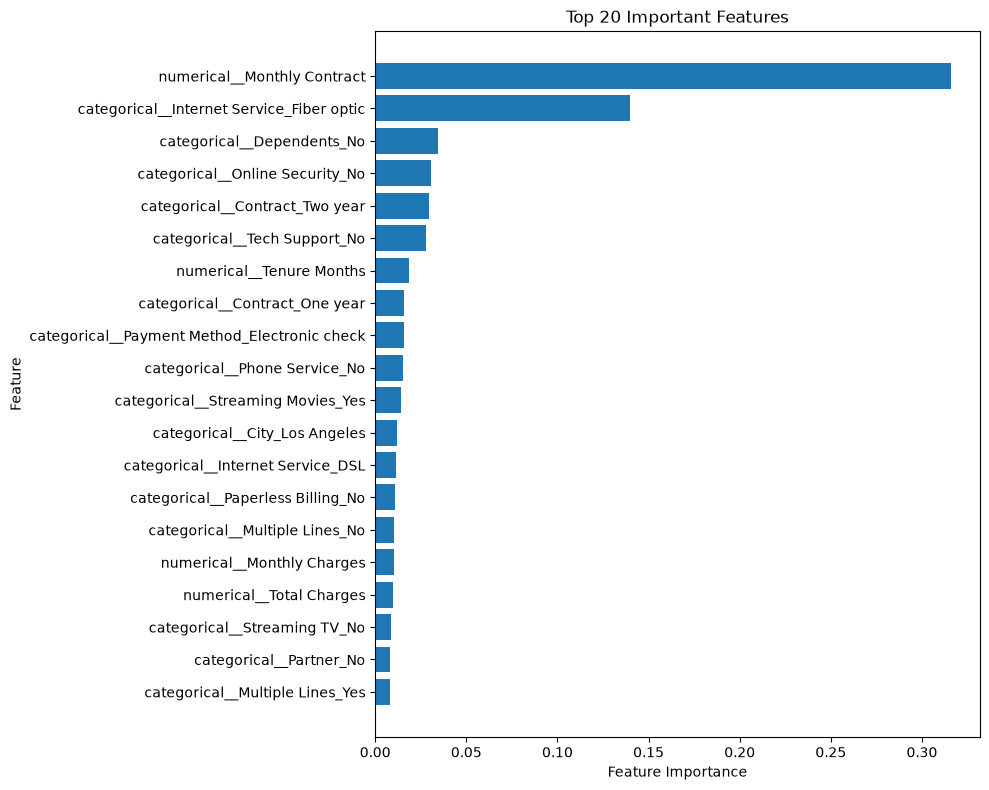

<Axes: title={'center': 'Top 20 Important Features'}, xlabel='Feature Importance', ylabel='Feature'>

In [62]:
create_feature_importance(
    xgb_model,
    feature_names
)

In [106]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
explainer = shap.TreeExplainer(xgb_model)

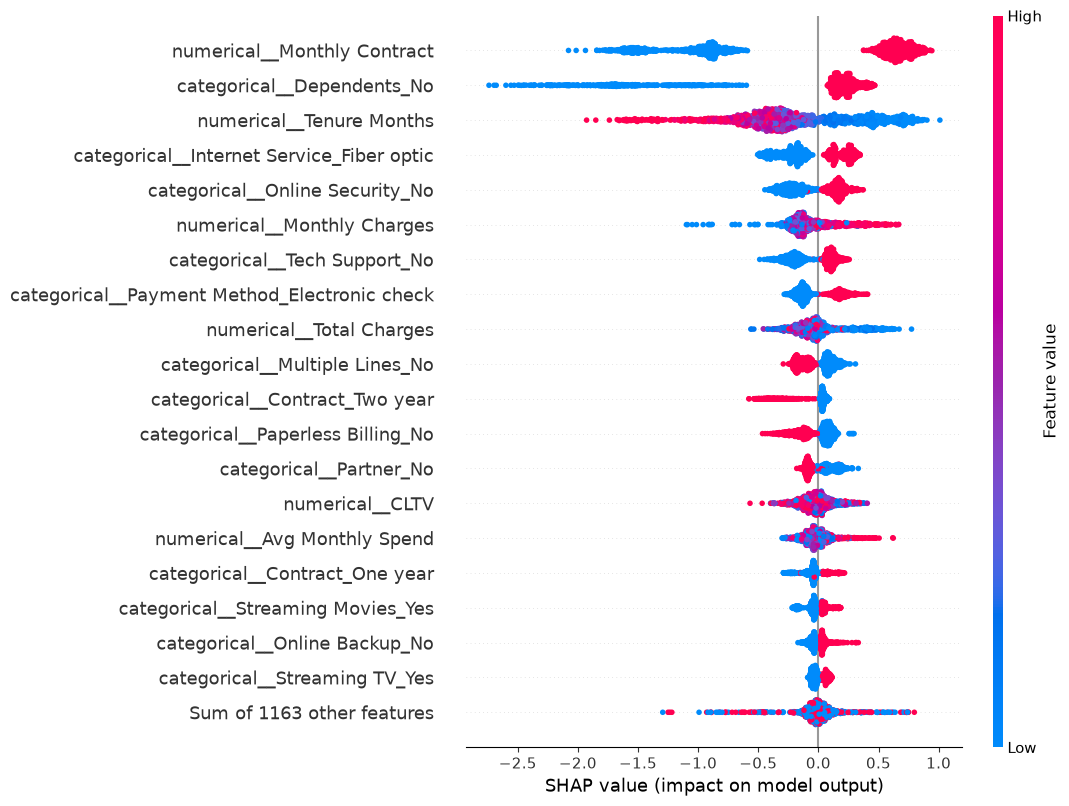

In [107]:
shap_values = explainer(X_test_processed)
feature_names = preprocessor.get_feature_names_out()
shap_values.feature_names = list(feature_names)
shap.plots.beeswarm(
    shap_values,
    max_display=20
)

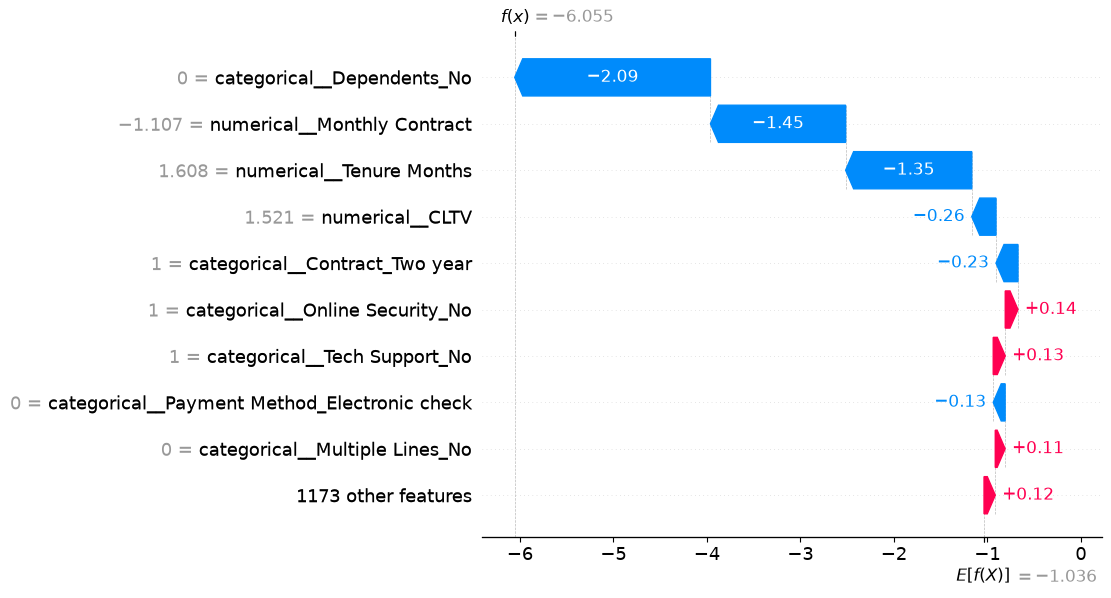

In [111]:
customer = 15

customer_shap = shap_values[customer]
if hasattr(X_test_processed, "toarray"):
    customer_shap.data = X_test_processed[customer].toarray().ravel()
shap.plots.waterfall(customer_shap)